In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import StratifiedKFold

from sklearn.naive_bayes import (
    GaussianNB,
    MultinomialNB,
    BernoulliNB,
    ComplementNB,
)


### Load Dataset

In [99]:
df = pd.read_csv("./cybersecurity_intrusion_data.csv")
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   object 
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   object 
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      7571 non-null   object 
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   object 
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 819.7+ KB


,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


### **Exploratory Data Analysis (EDA)**

### Check Missing Value

In [100]:
df.isna().sum()

,0
session_id,0
network_packet_size,0
protocol_type,0
login_attempts,0
session_duration,0
encryption_used,1966
ip_reputation_score,0
failed_logins,0
browser_type,0
unusual_time_access,0


### **Univariat Analysis**

### Attack vs Normal Distribution

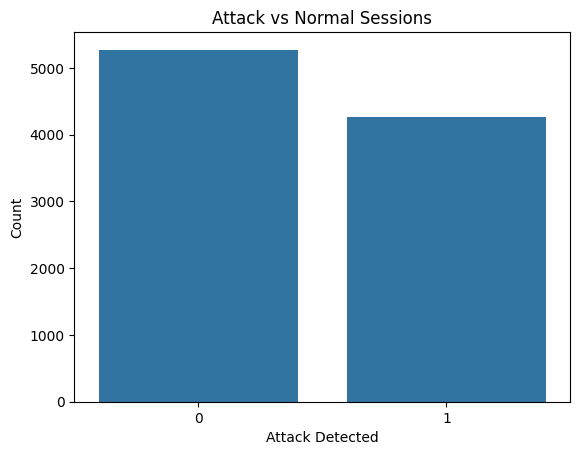

In [101]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="attack_detected", data=df)

plt.title("Attack vs Normal Sessions")
plt.xlabel("Attack Detected")
plt.ylabel("Count")

plt.show()

### **Bivariat Analysis**

### Packet Size vs Attack

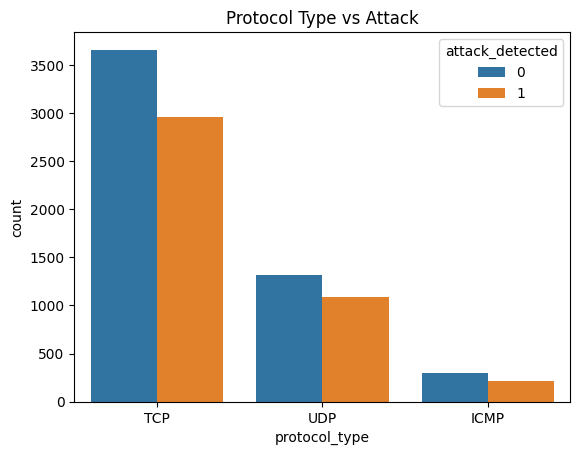

In [102]:
sns.countplot(x="protocol_type", hue="attack_detected", data=df)

plt.title("Protocol Type vs Attack")
plt.show()

### IP Reputation Score vs Attack

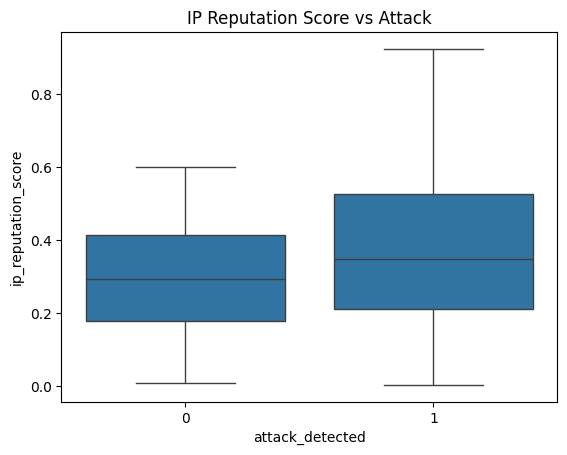

In [103]:
sns.boxplot(x="attack_detected", y="ip_reputation_score", data=df)

plt.title("IP Reputation Score vs Attack")
plt.show()

### **Multivariat Analysis**

### Heatmap Correlation

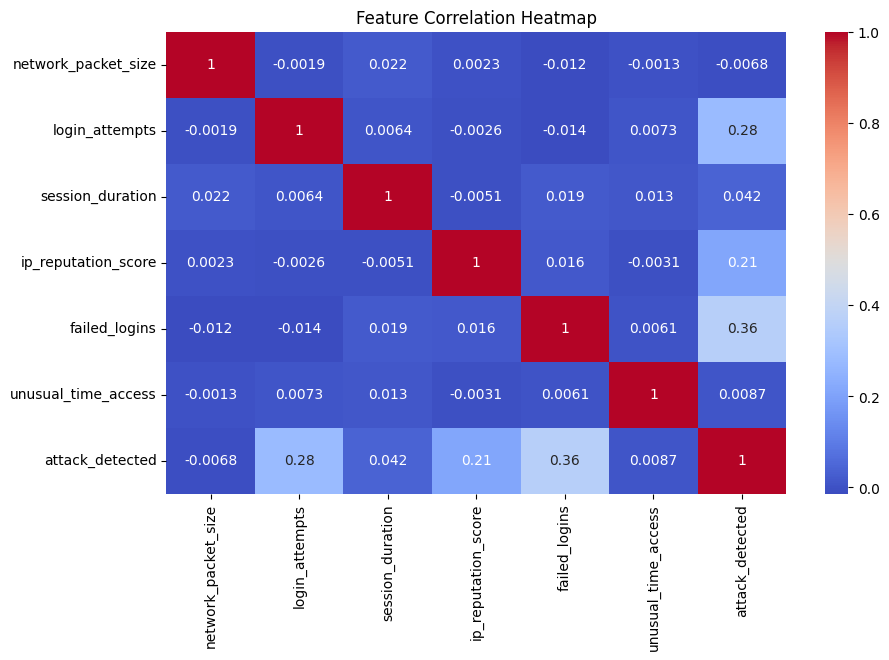

In [104]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.show()

### Handling Missing Value

In [105]:
df = df.drop(columns=["session_id"])
df["encryption_used"] = df["encryption_used"].fillna("Unknown")

### Data Preprocessing

In [106]:
cat_cols = ["protocol_type", "encryption_used", "browser_type"]

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

### Cross-Validation with Stratified K-Fold

In [107]:
X = df.drop("attack_detected", axis=1)
y = df["attack_detected"]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Load Naive Bayes Model

In [108]:
models = {
    "Gaussian NB": GaussianNB(),
    "Multinomial NB": MultinomialNB(),
    "Bernoulli NB": BernoulliNB(),
    "Complement NB": ComplementNB()
}

### Training

In [109]:
results = []
conf_results = []

for name, model in models.items():

    acc_scores = []
    precision_scores = []
    recall_scores = []
    f1_macro_scores = []
    f1_weighted_scores = []

    tn_total = fp_total = fn_total = tp_total = 0

    for train_index, test_index in skf.split(X, y):

        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        acc_scores.append(accuracy_score(y_test, y_pred))
        precision_scores.append(precision_score(y_test, y_pred))
        recall_scores.append(recall_score(y_test, y_pred))

        f1_macro_scores.append(f1_score(y_test, y_pred, average="macro"))
        f1_weighted_scores.append(f1_score(y_test, y_pred, average="weighted"))

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

        tn_total += tn
        fp_total += fp
        fn_total += fn
        tp_total += tp

    results.append({
        "Model": name,
        "Accuracy": np.mean(acc_scores),
        "Precision": np.mean(precision_scores),
        "Recall": np.mean(recall_scores),
        "F1 Macro": np.mean(f1_macro_scores),
        "F1 Weighted": np.mean(f1_weighted_scores)
    })

    conf_results.append({
        "Model": name,
        "TN": tn_total,
        "FP": fp_total,
        "FN": fn_total,
        "TP": tp_total
    })

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Evaluate Model

In [110]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd

results = []
conf_results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_weighted = f1_score(y_test, y_pred, average="weighted")

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1 Macro": f1_macro,
        "F1 Weighted": f1_weighted
    })

    conf_results.append({
        "Model": name,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

results_df = pd.DataFrame(results)
conf_df = pd.DataFrame(conf_results).set_index("Model")
results_df = results_df.sort_values(by="Accuracy", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1 Macro,F1 Weighted
0,Gaussian NB,0.814893,0.836707,0.727700,0.809734,0.813069
2,Bernoulli NB,0.550079,0.491525,0.204225,0.479785,0.500141
3,Complement NB,0.530676,0.472819,0.438967,0.521506,0.528558
1,Multinomial NB,0.527006,0.467866,0.427230,0.516811,0.524282


### Confusion Matrix

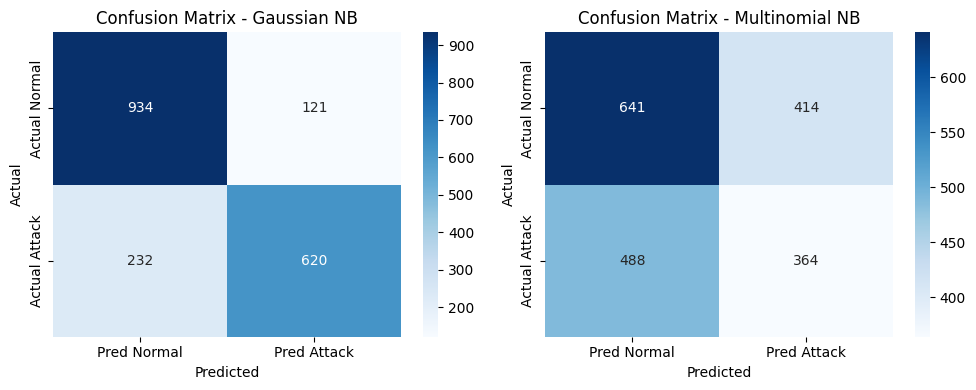

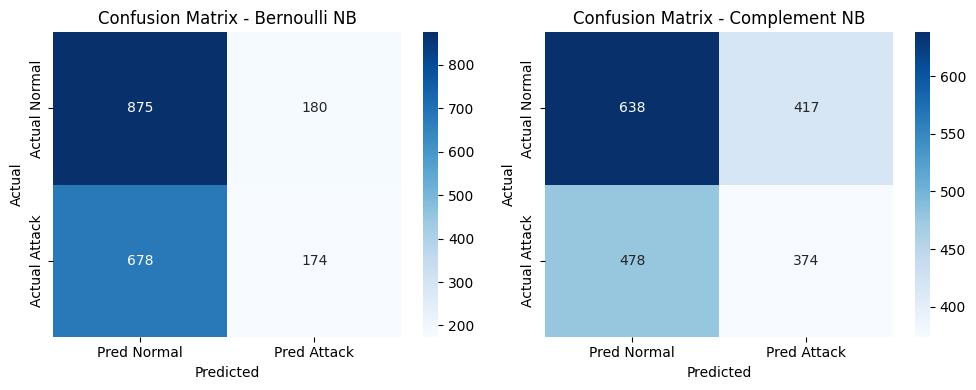

In [111]:
models = list(conf_df.index)

for i in range(0, len(models), 2):

    fig, axes = plt.subplots(1, 2, figsize=(10,4))

    for j in range(2):

        if i + j >= len(models):
            axes[j].axis("off")
            continue

        model_name = models[i + j]
        row = conf_df.loc[model_name]

        cm = np.array([
            [row["TN"], row["FP"]],
            [row["FN"], row["TP"]]
        ])

        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Pred Normal", "Pred Attack"],
            yticklabels=["Actual Normal", "Actual Attack"],
            ax=axes[j]
        )

        axes[j].set_title(f"Confusion Matrix - {model_name}")
        axes[j].set_xlabel("Predicted")
        axes[j].set_ylabel("Actual")

    plt.tight_layout()
    plt.show()

### Hyperparameter Tuning Naive Bayes Model using GridSearchCV

In [112]:
evaluation_results = []

for name, model in best_nb_models.items():

    acc_scores = []
    precision_scores = []
    recall_scores = []
    f1_macro_scores = []
    f1_weighted_scores = []

    for train_idx, test_idx in skf.split(X, y):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        acc_scores.append(accuracy_score(y_test, y_pred))
        precision_scores.append(precision_score(y_test, y_pred, zero_division=0))
        recall_scores.append(recall_score(y_test, y_pred, zero_division=0))

        f1_macro_scores.append(f1_score(y_test, y_pred, average="macro"))
        f1_weighted_scores.append(f1_score(y_test, y_pred, average="weighted"))

    evaluation_results.append({
        "Model": name,
        "Accuracy": np.mean(acc_scores),
        "Precision": np.mean(precision_scores),
        "Recall": np.mean(recall_scores),
        "F1 Macro": np.mean(f1_macro_scores),
        "F1 Weighted": np.mean(f1_weighted_scores)
    })

tuned_nb_df = pd.DataFrame(evaluation_results)

tuned_nb_df = tuned_nb_df.sort_values(by="Accuracy", ascending=False)

tuned_nb_df

,Model,Accuracy,Precision,Recall,F1 Macro,F1 Weighted
0,Gaussian NB,0.827511,0.844585,0.752575,0.823266,0.826162
2,Bernoulli NB,0.615705,0.570386,0.568711,0.611163,0.615577
1,Multinomial NB,0.522595,0.462004,0.410651,0.510735,0.518775
3,Complement NB,0.522071,0.461639,0.414405,0.510787,0.518627


### Naive Bayes Model Comparison

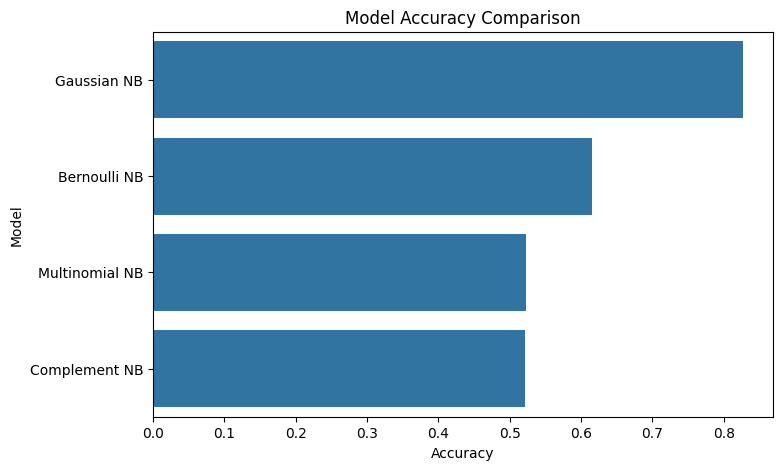

In [119]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Accuracy",
    y="Model",
    data=tuned_nb_df,
)

plt.title("Model Accuracy Comparison")
plt.show()

### Compare with other Model

In [114]:
!pip install xgboost lightgbm catboost

In [115]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [116]:
other_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric="logloss"),
    "LightGBM": LGBMClassifier(),
    "CatBoost": CatBoostClassifier(verbose=0)
}

### Training other model

In [117]:
compare_results = []

for name, model in other_models.items():

    acc_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []

    for train_idx, test_idx in skf.split(X, y):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        acc_scores.append(accuracy_score(y_test, y_pred))
        precision_scores.append(precision_score(y_test, y_pred, zero_division=0))
        recall_scores.append(recall_score(y_test, y_pred, zero_division=0))
        f1_scores.append(f1_score(y_test, y_pred, zero_division=0))

    compare_results.append({
        "Model": name,
        "Accuracy": np.mean(acc_scores),
        "Precision": np.mean(precision_scores),
        "Recall": np.mean(recall_scores),
        "F1 Score": np.mean(f1_scores)
    })

compare_df = pd.DataFrame(compare_results)
compare_df = compare_df.sort_values(by="Accuracy", ascending=False)

compare_df

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

[LightGBM] [Info] Number of positive: 3411, number of negative: 4218
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000217 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 798
[LightGBM] [Info] Number of data points in the train set: 7629, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.447110 -> initscore=-0.212356
[LightGBM] [Info] Start training from score -0.212356
[LightGBM] [Info] Number of positive: 3411, number of negative: 4218
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000248 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 798
[LightGBM] [Info] Number of data points in the train set: 7629, number of used features: 9
[LightGBM] [Info] [binary:Bo

,Model,Accuracy,Precision,Recall,F1 Score
5,CatBoost,0.893047,0.994216,0.765242,0.864729
2,Random Forest,0.892627,0.993590,0.764772,0.864195
4,LightGBM,0.890635,0.987231,0.765242,0.862105
3,XGBoost,0.884344,0.965323,0.768994,0.855928
1,Decision Tree,0.810527,0.778608,0.805346,0.791621
0,Logistic Regression,0.734820,0.721864,0.662050,0.690586


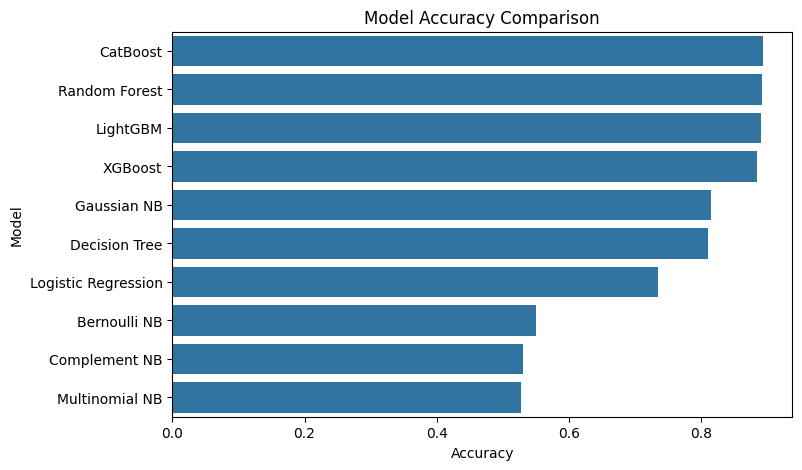

In [118]:
combined_df = pd.concat([results_df, compare_df], ignore_index=True)
combined_df = combined_df.sort_values(by="Accuracy", ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    x="Accuracy",
    y="Model",
    data=combined_df,
)

plt.title("Model Accuracy Comparison")
plt.show()